In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



In [30]:
df = pd.read_csv('C:\\Users\\mdjas\\Miniproject 1\\data\\stroop_data_template.csv')
print("Data Loaded:")
display(df.head(16))

Data Loaded:


,Participant,Accuracy,ReactionTime_s
0,1,97.2,1.70
1,2,97.2,1.67
2,3,97.8,2.03
3,4,98.8,2.25
4,5,100.0,1.03
5,6,99.2,1.46
6,7,98.2,1.07
7,8,98.6,1.29
8,9,93.1,2.52
9,10,96.9,1.40


C:\Users\mdjas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Cluster Centroids (Accuracy, ReactionTime):
[[98.43571429  1.55785714]
 [90.9         2.545     ]]


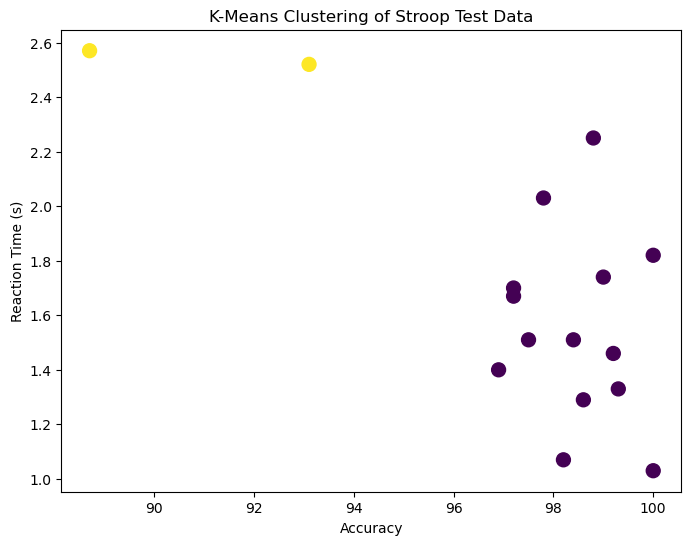


Cluster Labels Added to DataFrame:


,Participant,Accuracy,ReactionTime_s,ClusterLabel
0,1,97.2,1.70,0
1,2,97.2,1.67,0
2,3,97.8,2.03,0
3,4,98.8,2.25,0
4,5,100.0,1.03,0
5,6,99.2,1.46,0
6,7,98.2,1.07,0
7,8,98.6,1.29,0
8,9,93.1,2.52,1
9,10,96.9,1.40,0


In [31]:



# Data scaling (Accuracy & ReactionTime)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['Accuracy', 'ReactionTime_s']])

# K-Means clustering (2 clusters)
kmeans = KMeans(n_clusters=2, random_state=42)
df['ClusterLabel'] = kmeans.fit_predict(scaled_features)

# Cluster centroids (optional)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
print("Cluster Centroids (Accuracy, ReactionTime):")
print(centroids)

# Visualization
plt.figure(figsize=(8,6))
plt.scatter(df['Accuracy'], df['ReactionTime_s'], c=df['ClusterLabel'], cmap='viridis', s=100)
plt.xlabel('Accuracy')
plt.ylabel('Reaction Time (s)')
plt.title('K-Means Clustering of Stroop Test Data')
plt.show()

# Step 2 complete - cluster labels added
print("\nCluster Labels Added to DataFrame:")
display(df)

Confusion Matrix - SVM:
[[4 0]
 [0 0]]


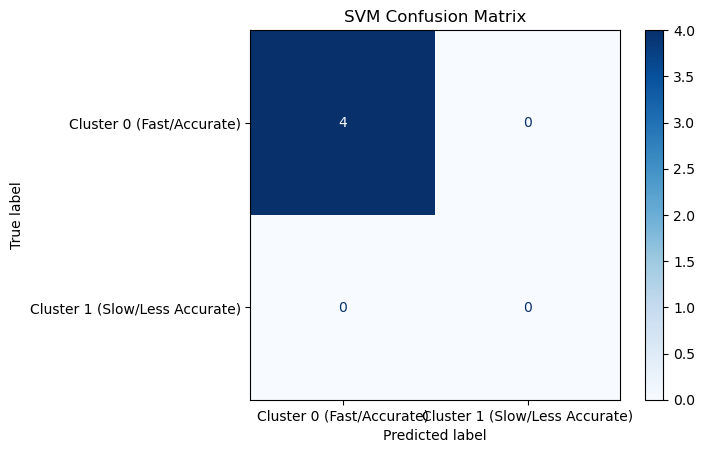

Confusion Matrix - Decision Tree:
[[4 0]
 [0 0]]


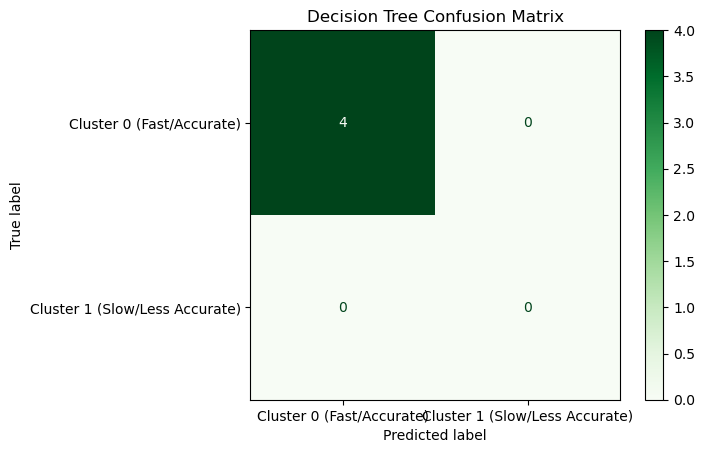

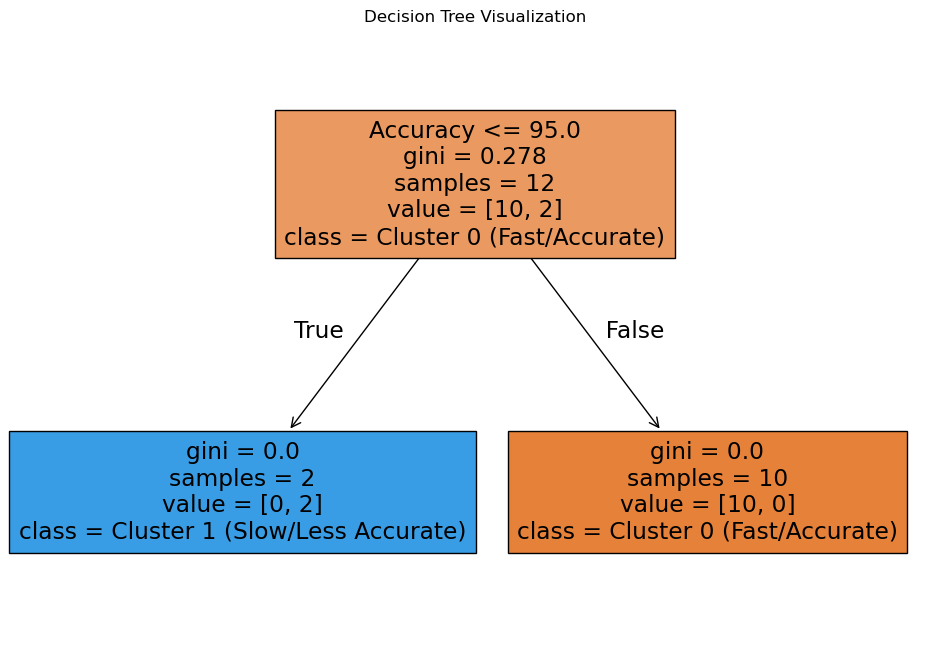

In [32]:
# ---- SVM Classifier ----
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=[0,1])
print("Confusion Matrix - SVM:")
print(cm_svm)

# Better visualization with labels
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm,
 display_labels=["Cluster 0 (Fast/Accurate)", "Cluster 1 (Slow/Less Accurate)"])
disp_svm.plot(cmap="Blues", values_format="d")
plt.title("SVM Confusion Matrix")
plt.show()


# ---- Decision Tree Classifier ----
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Confusion matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=[0,1])
print("Confusion Matrix - Decision Tree:")
print(cm_dt)

# Better visualization with labels
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt,display_labels=["Cluster 0 (Fast/Accurate)", "Cluster 1 (Slow/Less Accurate)"])
disp_dt.plot(cmap="Greens", values_format="d")
plt.title("Decision Tree Confusion Matrix")
plt.show()


# ---- Decision Tree Visualization ----
plt.figure(figsize=(12,8))
plot_tree(dt_model,
          feature_names=['Accuracy','ReactionTime_s'],
          class_names=['Cluster 0 (Fast/Accurate)','Cluster 1 (Slow/Less Accurate)'],
          filled=True)
plt.title("Decision Tree Visualization")
plt.show()
